### Pseudocode for Ford-Fulkerson Algorithm

#### Initialize the Graph
- Represent the graph as an adjacency matrix `graph`, where `graph[u][v]` is the capacity of the edge from node `u` to node `v`.
- Define the `source` and `sink` nodes.
- Make a copy of the graph to use as the residual graph
- Initialize `parent` list to store the path (`-1` for unvisited nodes).
- Set `max_flow` to `0` to keep track of the total flow.
- Create a `flows` matrix to record the actual flow for visualization.

#### Find Augmenting Paths
- Start a loop to find augmenting paths as long as they exist.
- Perform Breadth-First Search (BFS) to find a path from `source` to `sink`:
  - Mark all nodes as unvisited.
  - Start the BFS from the `source`, enqueue it, and mark it as visited.
  - For each node in the queue, iterate through its neighbors:
    - If a neighbor has remaining capacity and has not been visited, enqueue it, mark it as visited, and update the `parent` array.
    - Stop BFS if the `sink` is reached.

#### Augment the Flow
- If an augmenting path is found, calculate the bottleneck capacity (`path_flow`):
  - Trace back from the `sink` to the `source` using the `parent` array.
  - Take the minimum residual capacity along the path.
- Update the `residual_graph`:
  - Reduce the forward edge capacity by `path_flow`.
  - Increase the reverse edge capacity by `path_flow`.
- Update the `flows` matrix to record the actual flow along the edges.
- Add `path_flow` to `max_flow`.x_flow.


The maximum flow is: 23


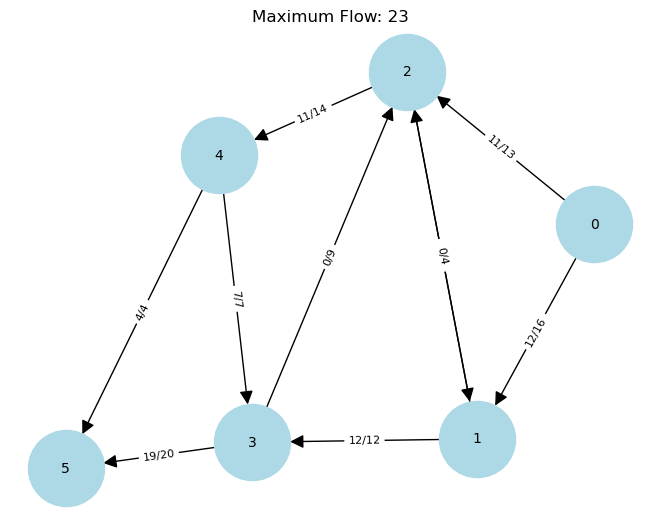

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

# Set up the graph using an adjacency matrix
graph = [[0, 16, 13, 0, 0, 0],
         [0, 0, 10, 12, 0, 0],
         [0, 4, 0, 0, 14, 0],
         [0, 0, 9, 0, 0, 20],
         [0, 0, 0, 7, 0, 4],
         [0, 0, 0, 0, 0, 0]]

source = 0
sink = 5

# Make a copy of the graph to use as the residual graph
residual_graph = [row[:] for row in graph]
parent = [-1] * len(graph)
max_flow = 0
# track the flow for visualization later
flows = [[0] * len(graph) for _ in range(len(graph))]

# start searching for paths using BFS
augmenting_path_exists = True
while augmenting_path_exists:
    visited = [False] * len(residual_graph)
    queue = deque([source])
    visited[source] = True

    # use BFS to check if there’s a path to the sink
    augmenting_path_exists = False
    while queue:
        u = queue.popleft()
        for v, capacity in enumerate(residual_graph[u]):
            if not visited[v] and capacity > 0:
                queue.append(v)
                visited[v] = True
                parent[v] = u
                if v == sink:
                    augmenting_path_exists = True
                    break
        if augmenting_path_exists:
            break

    # if there's a valid path, calculate the bottleneck capacity
    if augmenting_path_exists:
        path_flow = float('Inf')
        v = sink
        while v != source:
            u = parent[v]
            path_flow = min(path_flow, residual_graph[u][v])
            v = parent[v]

        # update capacities in the residual graph and track the flow
        v = sink
        while v != source:
            u = parent[v]
            residual_graph[u][v] -= path_flow
            residual_graph[v][u] += path_flow
            flows[u][v] += path_flow
            flows[v][u] -= path_flow
            v = parent[v]

        max_flow += path_flow

# print the final maximum flow
print(f"The maximum flow is: {max_flow}")

# visualization
G = nx.DiGraph()

# add all edges with their capacities and flows to the graph
for u in range(len(graph)):
    for v in range(len(graph[u])):
        if graph[u][v] > 0 or flows[u][v] > 0:
            label = f"{flows[u][v]}/{graph[u][v]}" if graph[u][v] > 0 else f"{flows[u][v]}"
            G.add_edge(u, v, capacity=graph[u][v], flow=flows[u][v], label=label)

pos = nx.spring_layout(G)
edge_labels = nx.get_edge_attributes(G, 'label')

# draw graph with the nodes and edges labeled
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=3000, font_size=10, arrowsize=20)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title(f"Maximum Flow: {max_flow}")
plt.show()